In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import re, html, warnings
warnings.filterwarnings('ignore')

from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import NMF, LatentDirichletAllocation
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

import ipykernel

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

In [2]:
# load data 
BASE_PATH = './data/'
abstract_raw = pd.read_excel(BASE_PATH + 'grants-with-abstract.xlsx',
                             sheet_name='Grants with abstract (2).csv')
aa = abstract_raw[abstract_raw['Sourcetype'] == 'AA'].copy()
aa = aa.dropna(subset=['Abstract'])
aa['Start Date'] = pd.to_datetime(aa['Start Date'], errors='coerce')
aa['Year'] = aa['Start Date'].dt.year
print(f'Loaded {len(aa):,} abstracts')

Loaded 2,873 abstracts


In [3]:
# full cleaning pipeline
def remove_nsf_boilerplate(text):
    if not isinstance(text, str): return ''
    text = re.sub(r'(?i)intellectual\s+merit\s*[:.*\-]?.*?(broader\s+impacts|$)', ' ', text, flags=re.DOTALL)
    text = re.sub(r'(?i)broader\s+impacts\s*[:.*\-]?.*', ' ', text, flags=re.DOTALL)
    return text.strip()

def clean_text(text):
    if not isinstance(text, str): return ''
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'&\w+;', ' ', text)
    text = text.lower()
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'\d+', ' ', text)
    text = re.sub(r'-', ' ', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\b\w{1,2}\b', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub(r'\[unreadable\]', ' ', text)
    text = re.sub(r'description\s*\(?provided by applicant\)?:?', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'project\s+summary', ' ', text, flags=re.IGNORECASE)
    return text

aa['abstract_clean'] = aa['Abstract'].apply(remove_nsf_boilerplate)
aa['full_text_clean'] = (
    aa['Title'].fillna('').apply(clean_text) + ' ' +
    aa['abstract_clean'].fillna('').apply(clean_text)
)

try:
    import nltk
    from nltk.stem import WordNetLemmatizer
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)
    lemmatizer = WordNetLemmatizer()
    aa['full_text_lemma'] = aa['full_text_clean'].apply(
        lambda t: ' '.join(lemmatizer.lemmatize(w) for w in t.split()))
    print('Lemmatization done.')
except ImportError:
    aa['full_text_lemma'] = aa['full_text_clean']
    print('nltk not found — skipping lemmatization.')

print('Cleaning done.')

Lemmatization done.
Cleaning done.


In [4]:
# stopword list
grant_noise = {
    # Grant/proposal language
    'research', 'project', 'award', 'grant', 'proposal', 'funded', 'funding',
    'investigator', 'principal', 'collaborative', 'collaboration', 'team',
    'work', 'working', 'study', 'studies', 'aims', 'aim', 'goal', 'goals',
    'proposed', 'propose', 'objective', 'objectives', 'researcher',
    # University/admin language
    'university', 'northeastern', 'national', 'science', 'engineering',
    'foundation', 'center', 'institute', 'program', 'programs',
    'support', 'supported', 'faculty', 'student', 'students', 'graduate',
    'undergraduate', 'education', 'educational', 'laboratory', 'lab', 'user',
    'conference', 'workshop', 'training', 'infrastructure', 'activities',
    'activity', 'mission', 'scientific', 'data', 'device', 'tool', 'method',
    'analysis', 'technique', 'area', 'technology', 'school', 'college',
    # Generic verbs/adjectives with no topic meaning
    'develop', 'development', 'developed', 'developing',
    'provide', 'provides', 'provided', 'providing',
    'include', 'including', 'includes', 'included',
    'approach', 'approaches', 'novel', 'new', 'enable', 'enabled',
    'use', 'used', 'using', 'uses', 'based',
    'result', 'results', 'resulting', 'impact', 'impacts',
    'important', 'significant', 'key', 'critical', 'potential',
    'ability', 'demonstrate', 'understand', 'understanding',
    'require', 'required', 'design', 'implement', 'implementation',
    'explore', 'consider', 'address', 'advance', 'advances', 'advanced',
    'high', 'large', 'small', 'specific', 'general', 'current', 'real',
    'different', 'multiple', 'fundamental', 'future', 'complex', 'effect',
    'knowledge', 'performance', 'framework', 'process', 'processes', 'need',
    'public', 'community', 'multi', 'groups', 'group',
    'time', 'state', 'level', 'scale', 'field',
    'represent', 'representation', 'model', 'change', 'changes',
    'problem', 'problems', 'experiment', 'challenge', 'open',
    # NSF boilerplate survivors
    'intellectual', 'merit', 'broader', 'criteria', 'criterion', 'deemed',
    'worthy', 'statutory', 'reflects', 'review',
    # HTML artifact words
    'andgt', 'andlt', 'nbsp', 'amp', 'br',
    # Short non-informative words that slip past the 2-char filter
    'will', 'also', 'well', 'can', 'may', 'such', 'thus',
    'this', 'these', 'their', 'been', 'have', 'from',
    # Lemmatization artifacts
    'ha',
    # Agency/program names
    'nsf', 'reu', 'stem',
    # NSF broader impacts / education boilerplate
    'participant', 'opportunity', 'diverse', 'diversity', 'minority',
    'institution', 'professional', 'career', 'experience',
    # Conference travel artifacts
    'travel', 'attend', 'attending', 'international', 'held', 'conext',
    # Location/admin artifacts
    'site', 'boston', 'ethic',
}
all_stops = list(set(ENGLISH_STOP_WORDS) | grant_noise)
print(f'Total stopwords: {len(all_stops):,}')

Total stopwords: 507


In [5]:
# refit NMF and LDA
N_TOPICS = 8

tfidf_vec = TfidfVectorizer(stop_words=all_stops, ngram_range=(1, 2),
                             max_features=3000, min_df=5, max_df=0.60)
count_vec = CountVectorizer(stop_words=all_stops, ngram_range=(1, 2),
                             max_features=3000, min_df=5, max_df=0.60)

tfidf_matrix = tfidf_vec.fit_transform(aa['full_text_lemma'])
count_matrix = count_vec.fit_transform(aa['full_text_lemma'])

nmf = NMF(n_components=N_TOPICS, random_state=42, max_iter=400)
nmf_doc_topics = nmf.fit_transform(tfidf_matrix)

lda = LatentDirichletAllocation(n_components=N_TOPICS, max_iter=25,
                                  learning_method='online', random_state=42, n_jobs=-1)
lda_doc_topics = lda.fit_transform(count_matrix)

aa['nmf_topic'] = nmf_doc_topics.argmax(axis=1)
aa['lda_topic'] = lda_doc_topics.argmax(axis=1)

nmf_labels = {
    0: 'AI & Machine Learning',
    1: 'Biomedical & Cancer Biology',
    2: 'Pure Mathematics',
    3: 'Networking & Communications',
    4: 'Materials Science & Condensed Matter',
    5: 'Public Health, Environment & Climate',
    6: 'Particle Physics',
    7: 'STEM Education & Broadening Participation',
}
lda_labels = {
    0: 'Environment & Climate',
    1: 'Networking & Communications',
    2: 'Public Health & Society',
    3: 'STEM Education & Broadening Participation',
    4: 'Physics & Materials Science',
    5: 'Cognitive & Computational Modeling',
    6: 'Biomedical & Molecular Biology',
    7: 'AI & Computer Science',
}
aa['nmf_label'] = aa['nmf_topic'].map(nmf_labels)
aa['lda_label'] = aa['lda_topic'].map(lda_labels)

print('Models refit. NMF topic counts:')
print(aa['nmf_label'].value_counts().to_string())

Models refit. NMF topic counts:
nmf_label
Public Health, Environment & Climate         912
Materials Science & Condensed Matter         474
Biomedical & Cancer Biology                  363
Networking & Communications                  356
AI & Machine Learning                        297
STEM Education & Broadening Participation    251
Pure Mathematics                             139
Particle Physics                              81


## 1. Topic Coherence, Are the Topics Internally Consistent?

In [6]:
# coherence score using NPMI (normalized pointwise mutual information)
# measures how often top words in a topic actually co-occur in documents
# higher = more coherent topic; range roughly -1 to 1, good topics score > 0.1
from itertools import combinations

def compute_coherence(model, vectorizer, docs_matrix, top_n=10):
    feature_names = vectorizer.get_feature_names_out()
    scores = []
    n_docs = docs_matrix.shape[0]

    for topic in model.components_:
        top_idx   = topic.argsort()[:-top_n - 1:-1]
        top_words = [feature_names[i] for i in top_idx]
        word_cols = [np.asarray(docs_matrix[:, i].todense()).flatten() > 0 for i in top_idx]

        pair_scores = []
        for (i, wi), (j, wj) in combinations(enumerate(top_words), 2):
            co_occur = np.sum(word_cols[i] & word_cols[j]) + 1  # +1 smoothing
            p_i  = (np.sum(word_cols[i]) + 1) / n_docs
            p_j  = (np.sum(word_cols[j]) + 1) / n_docs
            p_ij = co_occur / n_docs
            npmi = np.log(p_ij / (p_i * p_j)) / (-np.log(p_ij))
            pair_scores.append(npmi)
        scores.append(np.mean(pair_scores))
    return scores

nmf_coherence = compute_coherence(nmf, tfidf_vec, tfidf_matrix)
lda_coherence = compute_coherence(lda, count_vec, count_matrix)

print('NMF coherence per topic (higher = more coherent):')
for i, score in enumerate(nmf_coherence):
    print(f'  {nmf_labels[i]:<45} {score:.3f}')
print(f'  Mean NMF coherence: {np.mean(nmf_coherence):.3f}')
print()
print('LDA coherence per topic:')
for i, score in enumerate(lda_coherence):
    print(f'  {lda_labels[i]:<45} {score:.3f}')
print(f'  Mean LDA coherence: {np.mean(lda_coherence):.3f}')

NMF coherence per topic (higher = more coherent):
  AI & Machine Learning                         0.210
  Biomedical & Cancer Biology                   0.316
  Pure Mathematics                              0.457
  Networking & Communications                   0.301
  Materials Science & Condensed Matter          0.242
  Public Health, Environment & Climate          0.122
  Particle Physics                              0.684
  STEM Education & Broadening Participation     0.341
  Mean NMF coherence: 0.334

LDA coherence per topic:
  Environment & Climate                         0.156
  Networking & Communications                   0.164
  Public Health & Society                       0.110
  STEM Education & Broadening Participation     0.234
  Physics & Materials Science                   0.213
  Cognitive & Computational Modeling            0.244
  Biomedical & Molecular Biology                0.163
  AI & Computer Science                         0.091
  Mean LDA coherence: 0.172


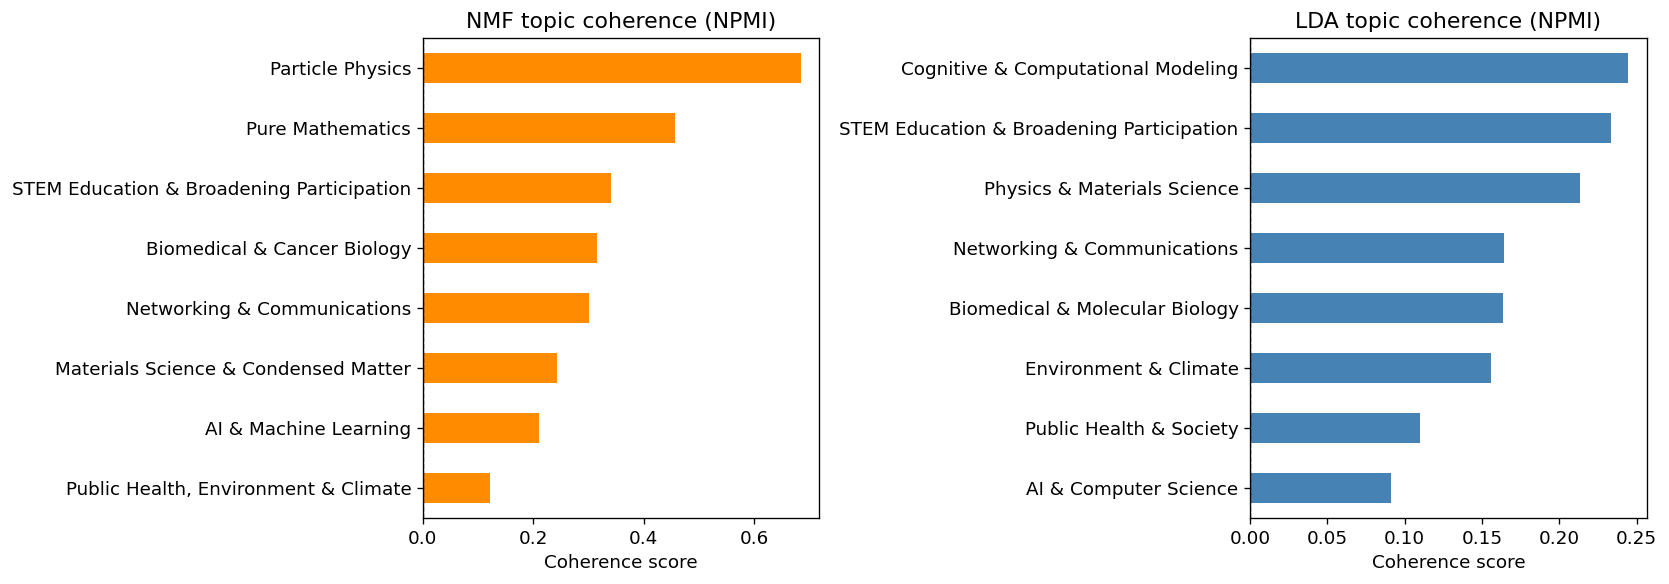

In [7]:
# bar chart comparing NMF vs LDA coherence per topic
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pd.Series(nmf_coherence, index=[nmf_labels[i] for i in range(N_TOPICS)]).sort_values().plot(
    kind='barh', ax=axes[0], color='darkorange')
axes[0].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[0].set_title('NMF topic coherence (NPMI)')
axes[0].set_xlabel('Coherence score')

pd.Series(lda_coherence, index=[lda_labels[i] for i in range(N_TOPICS)]).sort_values().plot(
    kind='barh', ax=axes[1], color='steelblue')
axes[1].axvline(0, color='black', linewidth=0.8, linestyle='--')
axes[1].set_title('LDA topic coherence (NPMI)')
axes[1].set_xlabel('Coherence score')

plt.tight_layout()
import os; os.makedirs('figures', exist_ok=True)
plt.savefig('figures/coherence_scores.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Assignment Confidence, How Clean Are the Topic Assignments?

In [8]:
# for each grant: what is the probability of its top topic vs second topic?
# high top-topic probability = confident assignment
# low top-topic probability = grant sits between topics, assignment is uncertain

# NMF: normalize doc-topic matrix to get probabilities
nmf_probs = nmf_doc_topics / (nmf_doc_topics.sum(axis=1, keepdims=True) + 1e-10)
aa['nmf_top_prob']    = nmf_probs.max(axis=1)
aa['nmf_second_prob'] = np.sort(nmf_probs, axis=1)[:, -2]
aa['nmf_confidence']  = aa['nmf_top_prob'] - aa['nmf_second_prob']

# LDA: already probabilities
aa['lda_top_prob']    = lda_doc_topics.max(axis=1)
aa['lda_second_prob'] = np.sort(lda_doc_topics, axis=1)[:, -2]
aa['lda_confidence']  = aa['lda_top_prob'] - aa['lda_second_prob']

# confidence thresholds
for model, col in [('NMF', 'nmf_top_prob'), ('LDA', 'lda_top_prob')]:
    vals = aa[col]
    print(f'{model} top-topic probability:')
    print(f'  Mean   : {vals.mean():.3f}')
    print(f'  Median : {vals.median():.3f}')
    print(f'  > 0.5  : {(vals > 0.5).sum():,} grants  ({(vals > 0.5).mean()*100:.1f}%)')
    print(f'  > 0.7  : {(vals > 0.7).sum():,} grants  ({(vals > 0.7).mean()*100:.1f}%)')
    print(f'  < 0.3  : {(vals < 0.3).sum():,} grants  ({(vals < 0.3).mean()*100:.1f}%) — ambiguous')
    print()

NMF top-topic probability:
  Mean   : 0.645
  Median : 0.626
  > 0.5  : 2,010 grants  (70.0%)
  > 0.7  : 1,111 grants  (38.7%)
  < 0.3  : 58 grants  (2.0%) — ambiguous

LDA top-topic probability:
  Mean   : 0.643
  Median : 0.626
  > 0.5  : 2,058 grants  (71.6%)
  > 0.7  : 1,094 grants  (38.1%)
  < 0.3  : 39 grants  (1.4%) — ambiguous



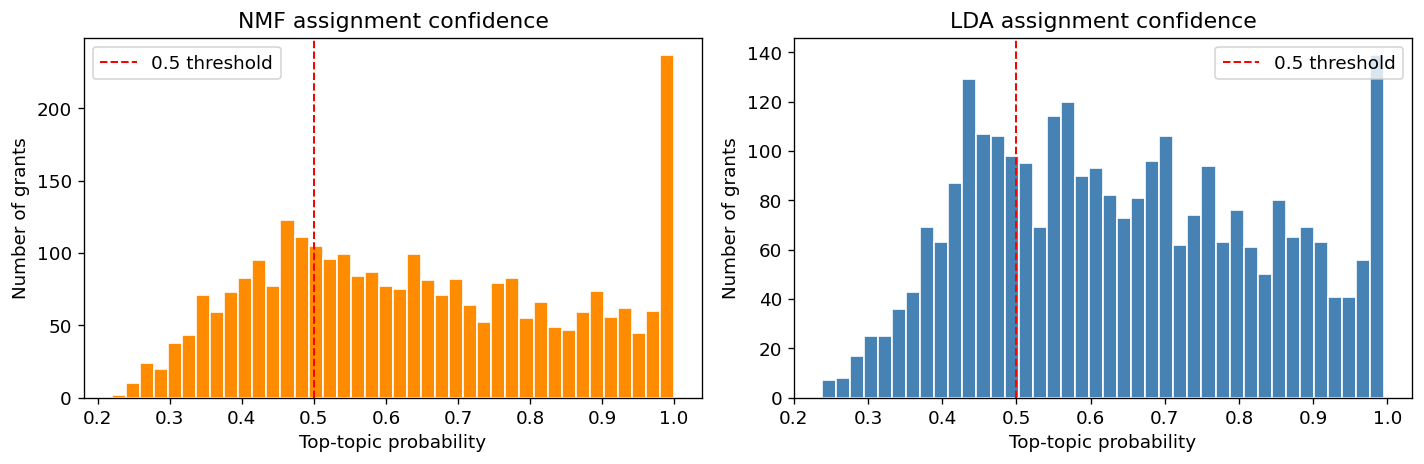

In [9]:
# histogram of assignment confidence for NMF and LDA
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(aa['nmf_top_prob'], bins=40, color='darkorange', edgecolor='white')
axes[0].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
axes[0].set_xlabel('Top-topic probability')
axes[0].set_ylabel('Number of grants')
axes[0].set_title('NMF assignment confidence')
axes[0].legend()

axes[1].hist(aa['lda_top_prob'], bins=40, color='steelblue', edgecolor='white')
axes[1].axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
axes[1].set_xlabel('Top-topic probability')
axes[1].set_ylabel('Number of grants')
axes[1].set_title('LDA assignment confidence')
axes[1].legend()

plt.tight_layout()
plt.savefig('figures/assignment_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

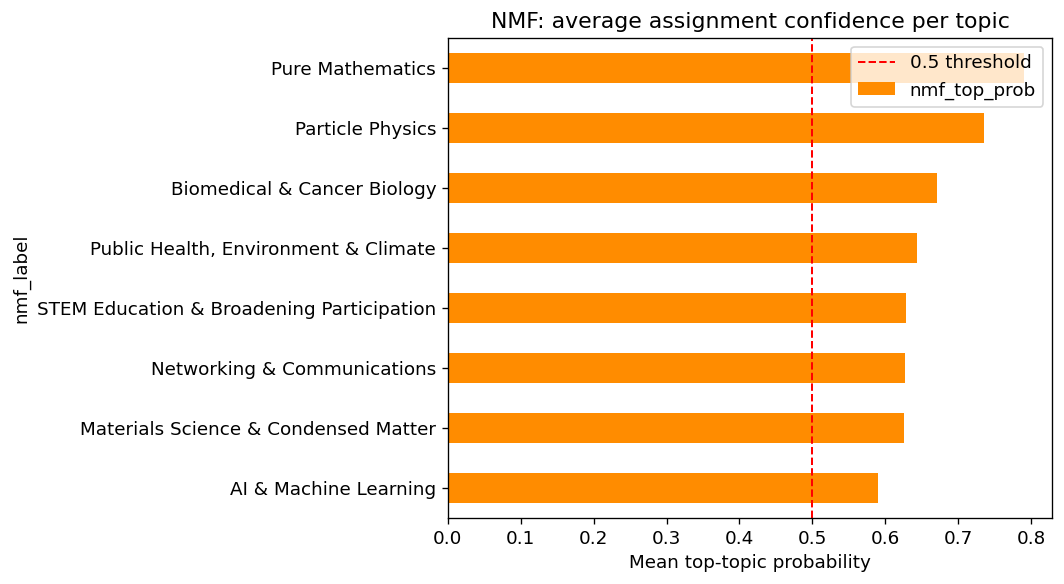

In [10]:
# confidence per topic — are some topics harder to assign than others?
nmf_conf_by_topic = aa.groupby('nmf_label')['nmf_top_prob'].mean().sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
nmf_conf_by_topic.plot(kind='barh', ax=ax, color='darkorange')
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.2, label='0.5 threshold')
ax.set_xlabel('Mean top-topic probability')
ax.set_title('NMF: average assignment confidence per topic')
#ax.set_ylabel('')
ax.legend()
plt.tight_layout()
plt.savefig('figures/confidence_per_topic.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Manual Spot-Check, Read Actual Abstracts per Topic

In [11]:
# sample 5 grants per NMF topic and print title + first 300 chars of abstract
# read these and judge whether the label makes sense
# high-confidence grants sampled first (top_prob > 0.6)
print('NMF TOPIC SPOT-CHECK — 5 grants per topic')
print('' * 70)

for topic_id, label in nmf_labels.items():
    subset = aa[(aa['nmf_topic'] == topic_id) & (aa['nmf_top_prob'] > 0.6)]
    if len(subset) < 5:
        subset = aa[aa['nmf_topic'] == topic_id]
    sample = subset.sample(min(5, len(subset)), random_state=42)

    print(f'\nTOPIC: {label}  ({(aa["nmf_topic"]==topic_id).sum()} grants)')
    for _, row in sample.iterrows():
        title    = str(row['Title'])[:80] if pd.notna(row['Title']) else 'No title'
        abstract = str(row['Abstract'])[:250] if pd.notna(row['Abstract']) else ''
        print(f'  [{row["nmf_top_prob"]:.2f}] {title}')
        print(f'         {abstract}...')
        print()

NMF TOPIC SPOT-CHECK — 5 grants per topic


TOPIC: AI & Machine Learning  (297 grants)
  [1.00] NRI: FND: Coordinating and Incorporating Trust in Teams of Humans and Robots wit
         The decreasing cost and increasing sophistication of robot hardware has created new opportunities for applications where teams of robots can be deployed in combination with skilled humans to automate labor-intensive tasks. However, if such systems ar...

  [1.00] Career: IIS: RI: Improving Multi-Agent Reinforcement Learning for Cooperative, P
         As intelligent systems become more prevalent, these systems will need to coordinate with each other (e.g., apps, robots, autonomous cars), resulting in multi-agent systems. Allowing multi-agent systems to learn will let them operate in more complex a...

  [0.67] CPS: Medium: Collaborative Research: Holistic Design Methodology for Automated I
         This project develops a framework for design automation of cyber-physical systems to augment human interac

## 4. Classifier, Can We Predict Topic from Text?

In [12]:
# train a logistic regression classifier on NMF topic labels
# if it achieves high cross-validation accuracy, the topics are text-separable and trustworthy
# use TF-IDF features, same stopwords, 5-fold stratified cross-validation

tfidf_clf = TfidfVectorizer(stop_words=all_stops, ngram_range=(1, 2),
                             max_features=5000, min_df=3)
X = tfidf_clf.fit_transform(aa['full_text_lemma'])
y = aa['nmf_topic'].values

clf = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
cv  = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(clf, X, y, cv=cv, scoring='accuracy')

print('Logistic Regression cross-validation accuracy (5-fold):')
for i, s in enumerate(cv_scores):
    print(f'  Fold {i+1}: {s:.3f}')
print(f'  Mean  : {cv_scores.mean():.3f}')
print(f'  Std   : {cv_scores.std():.3f}')

# > 0.85 = topics are well-separated and trustworthy

Logistic Regression cross-validation accuracy (5-fold):
  Fold 1: 0.911
  Fold 2: 0.894
  Fold 3: 0.915
  Fold 4: 0.909
  Fold 5: 0.899
  Mean  : 0.906
  Std   : 0.008


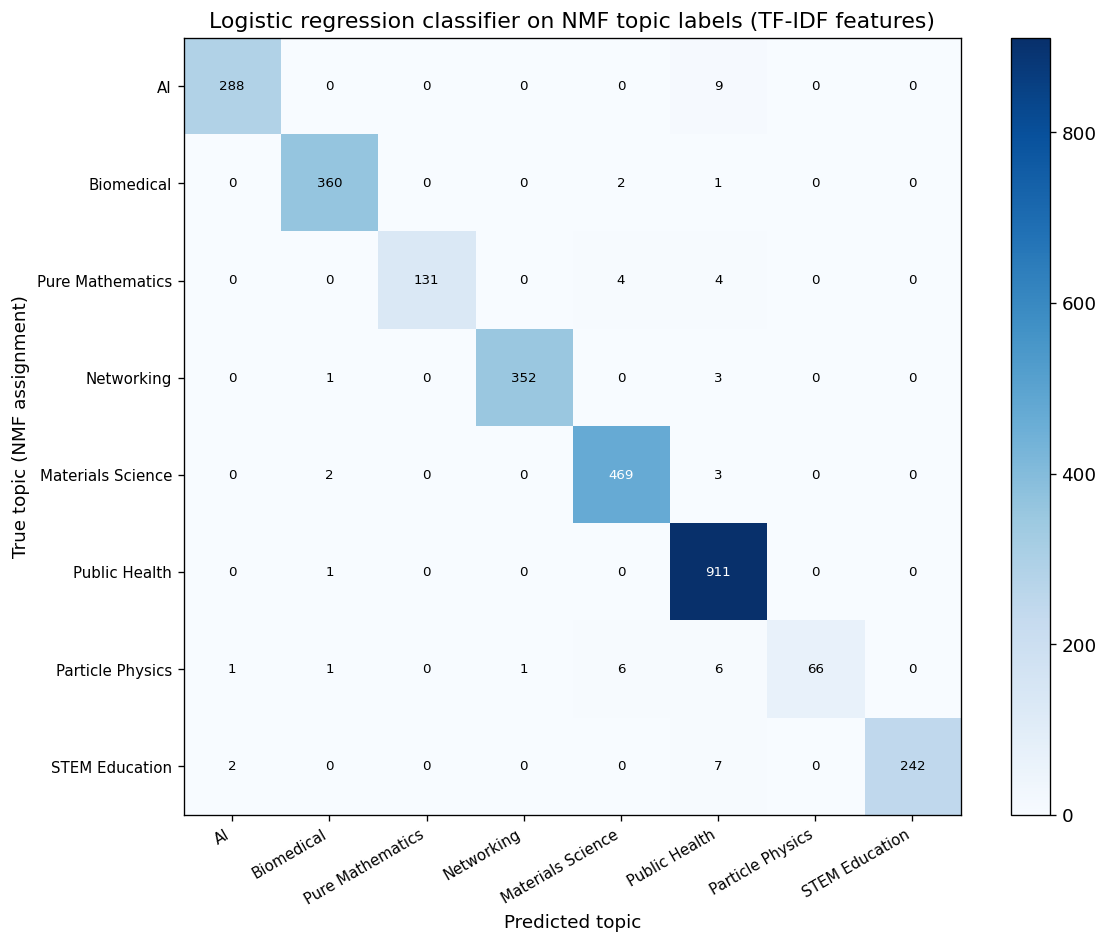


Per-topic classification report:
                   precision    recall  f1-score   support

               AI       0.99      0.97      0.98       297
       Biomedical       0.99      0.99      0.99       363
 Pure Mathematics       1.00      0.94      0.97       139
       Networking       1.00      0.99      0.99       356
Materials Science       0.98      0.99      0.98       474
    Public Health       0.97      1.00      0.98       912
 Particle Physics       1.00      0.81      0.90        81
   STEM Education       1.00      0.96      0.98       251

         accuracy                           0.98      2873
        macro avg       0.99      0.96      0.97      2873
     weighted avg       0.98      0.98      0.98      2873



In [33]:
# confusion matrix — which topics get confused with each other?
# fit on full dataset and predict to show confusion pattern
#trained on text features
clf.fit(X, y)
y_pred = clf.predict(X)

topic_names_short = [nmf_labels[i].split(' &')[0].split(',')[0] for i in range(N_TOPICS)]
cm = confusion_matrix(y, y_pred)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(N_TOPICS))
ax.set_yticks(range(N_TOPICS))
ax.set_xticklabels(topic_names_short, rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(topic_names_short, fontsize=9)
plt.colorbar(im, ax=ax)
for i in range(N_TOPICS):
    for j in range(N_TOPICS):
        ax.text(j, i, str(cm[i, j]), ha='center', va='center', fontsize=8,
                color='white' if cm[i, j] > cm.max() * 0.5 else 'black')
ax.set_xlabel('Predicted topic')
ax.set_ylabel('True topic (NMF assignment)')
ax.set_title('Logistic regression classifier on NMF topic labels (TF-IDF features)')
plt.tight_layout()
plt.savefig('figures/classifier_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nPer-topic classification report:')
print(classification_report(y, y_pred, target_names=topic_names_short))

## 5. UMAP, Visualize Grants in 2D Using BERT Embeddings

In [14]:
# generate BERT sentence embeddings for all abstracts
# these capture semantic meaning, not just word frequency

try:
    from sentence_transformers import SentenceTransformer
    import umap
    UMAP_OK = True
except ImportError:
    UMAP_OK = False
    print('Missing: pip install sentence-transformers umap-learn')

if UMAP_OK:
    aa['full_text_orig'] = aa['Title'].fillna('') + ' ' + aa['abstract_clean'].fillna('')
    embedder   = SentenceTransformer('all-MiniLM-L6-v2')
    embeddings = embedder.encode(aa['full_text_orig'].tolist(),
                                  show_progress_bar=True, batch_size=64)
    print(f'Embeddings shape: {embeddings.shape}')

Batches: 100%|██████████| 45/45 [00:11<00:00,  4.00it/s]

Embeddings shape: (2873, 384)


In [15]:
# reduce to 2D with UMAP
# n_neighbors controls how local vs global the layout is (15 is default)
# min_dist controls how tightly clusters are packed
if UMAP_OK:
    reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.2,
                         metric='cosine', random_state=42)
    coords = reducer.fit_transform(embeddings)
    aa['umap_x'] = coords[:, 0]
    aa['umap_y'] = coords[:, 1]
    print('UMAP done.')

OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


UMAP done.


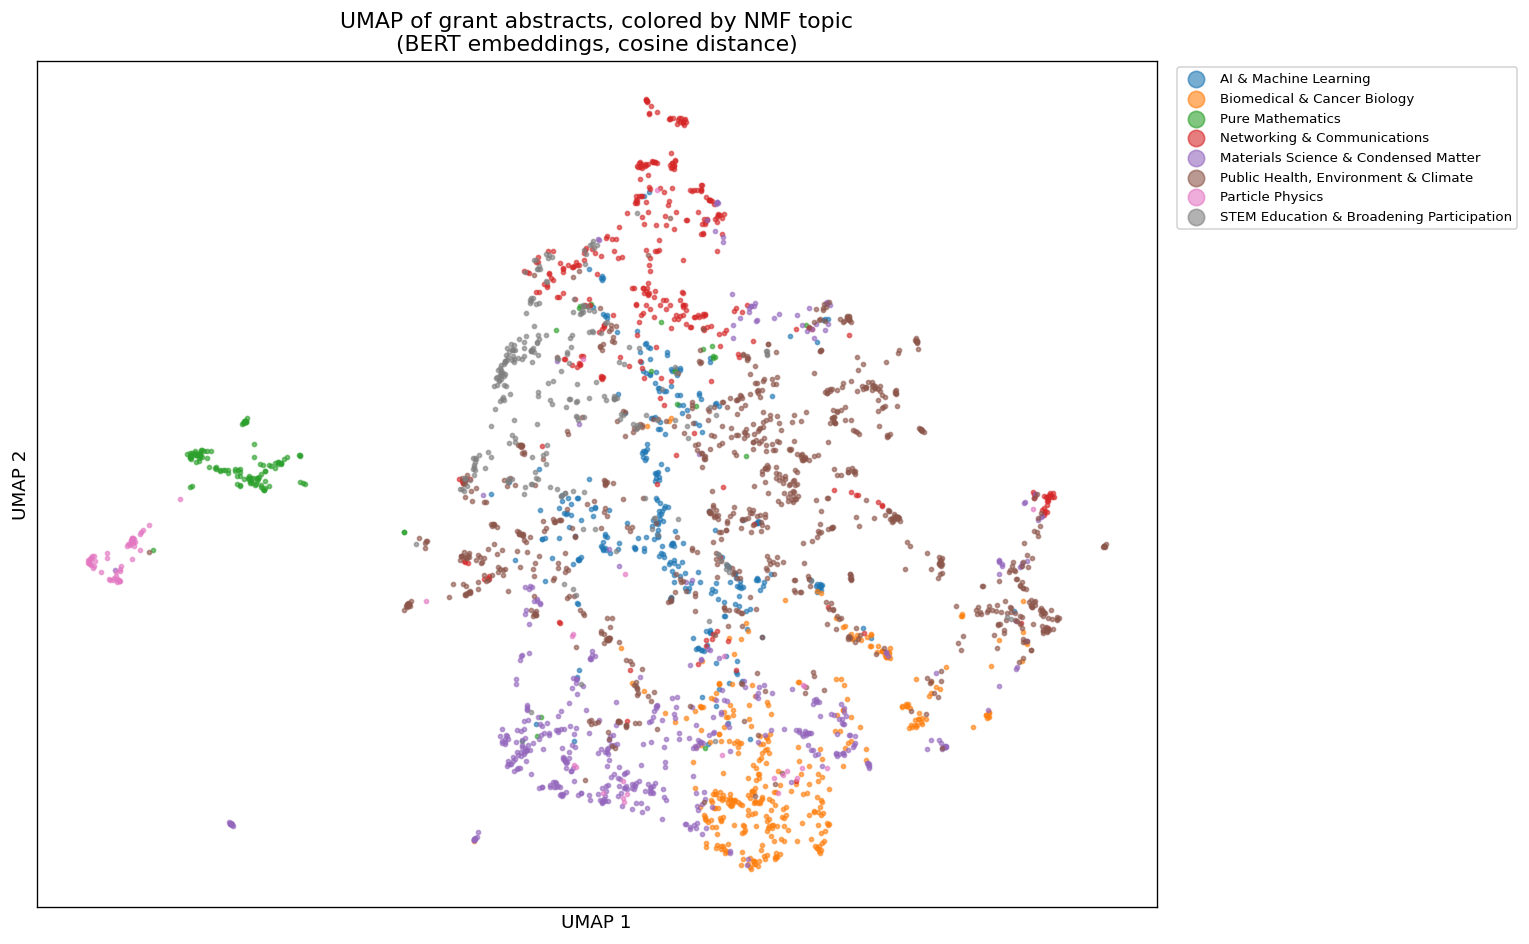

In [38]:
# UMAP plot colored by NMF topic
# if topics form visible clusters, the NMF assignments reflect real semantic structure
if UMAP_OK:
    colors = plt.cm.tab10.colors

    fig, ax = plt.subplots(figsize=(13, 8))
    for topic_id, label in nmf_labels.items():
        mask = aa['nmf_topic'] == topic_id
        ax.scatter(aa.loc[mask, 'umap_x'], aa.loc[mask, 'umap_y'],
                   label=label, s=6, alpha=0.6, color=colors[topic_id])

    ax.legend(fontsize=8, markerscale=4, loc='upper center',
               bbox_to_anchor=(1.17, 1))
    ax.set_title('UMAP of grant abstracts, colored by NMF topic\n(BERT embeddings, cosine distance)')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig('figures/umap_nmf_topics.png', dpi=150, bbox_inches='tight')
    plt.show()

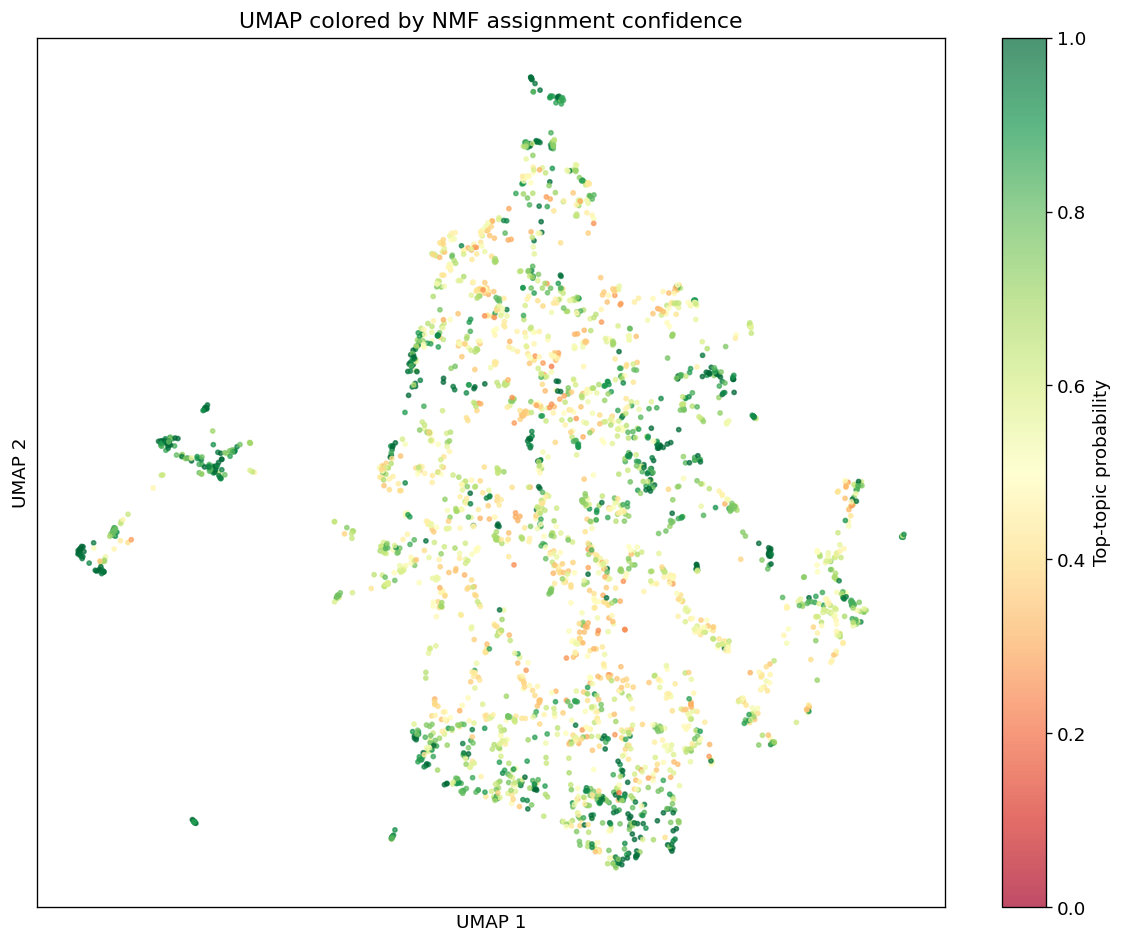

In [17]:
# UMAP plot colored by assignment confidence
# dark = high confidence, light = ambiguous
if UMAP_OK:
    fig, ax = plt.subplots(figsize=(10, 8))
    sc = ax.scatter(aa['umap_x'], aa['umap_y'],
                    c=aa['nmf_top_prob'], cmap='RdYlGn',
                    s=6, alpha=0.7, vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, label='Top-topic probability')
    ax.set_title('UMAP colored by NMF assignment confidence')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    ax.set_xticks([])
    ax.set_yticks([])
    plt.tight_layout()
    plt.savefig('figures/umap_confidence.png', dpi=150, bbox_inches='tight')
    plt.show()

## 6. Within-Topic Deep Dive, What Is Northeastern Actually Doing?

In [18]:
# for each NMF topic: find the most distinctive terms within that subset
# uses inverse document frequency — low IDF = word is rare outside this topic = distinctive
# this answers: within Biomedical, what specifically is NU working on?
print('WITHIN-TOPIC DISTINCTIVE TERMS')
print(' ' * 60)

within_topic_terms = {}

for topic_id, label in nmf_labels.items():
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 15:
        continue
    tv = TfidfVectorizer(stop_words=all_stops, max_features=300,
                          ngram_range=(1, 2), min_df=2)
    tv.fit_transform(subset)
    # lowest IDF = most characteristic of this topic
    top_terms = pd.Series(tv.idf_, index=tv.get_feature_names_out())\
                  .sort_values().head(20).index.tolist()
    within_topic_terms[label] = top_terms
    print(f'\n{label} ({len(subset)} grants):')
    print('  ' + ' | '.join(top_terms[:15]))

WITHIN-TOPIC DISTINCTIVE TERMS
                                                            

AI & Machine Learning (297 grants):
  learning | evaluation | human | task | machine | application | environment | computer | algorithm | information | machine learning | world | neural | help | control

Biomedical & Cancer Biology (363 grants):
  cell | description | mechanism | applicant | description applicant | human | function | role | disease | molecular | protein | drug | tissue | cellular | vivo

Pure Mathematics (139 grants):
  theory | geometry | algebraic | mathematics | algebra | mathematical | structure | geometric | application | physic | object | space | connection | invariant | algebraic geometry

Networking & Communications (356 grants):
  network | application | evaluation | communication | wireless | software | security | algorithm | information | existing | power | networking | platform | access | low

Materials Science & Condensed Matter (474 grants):
  material | structure

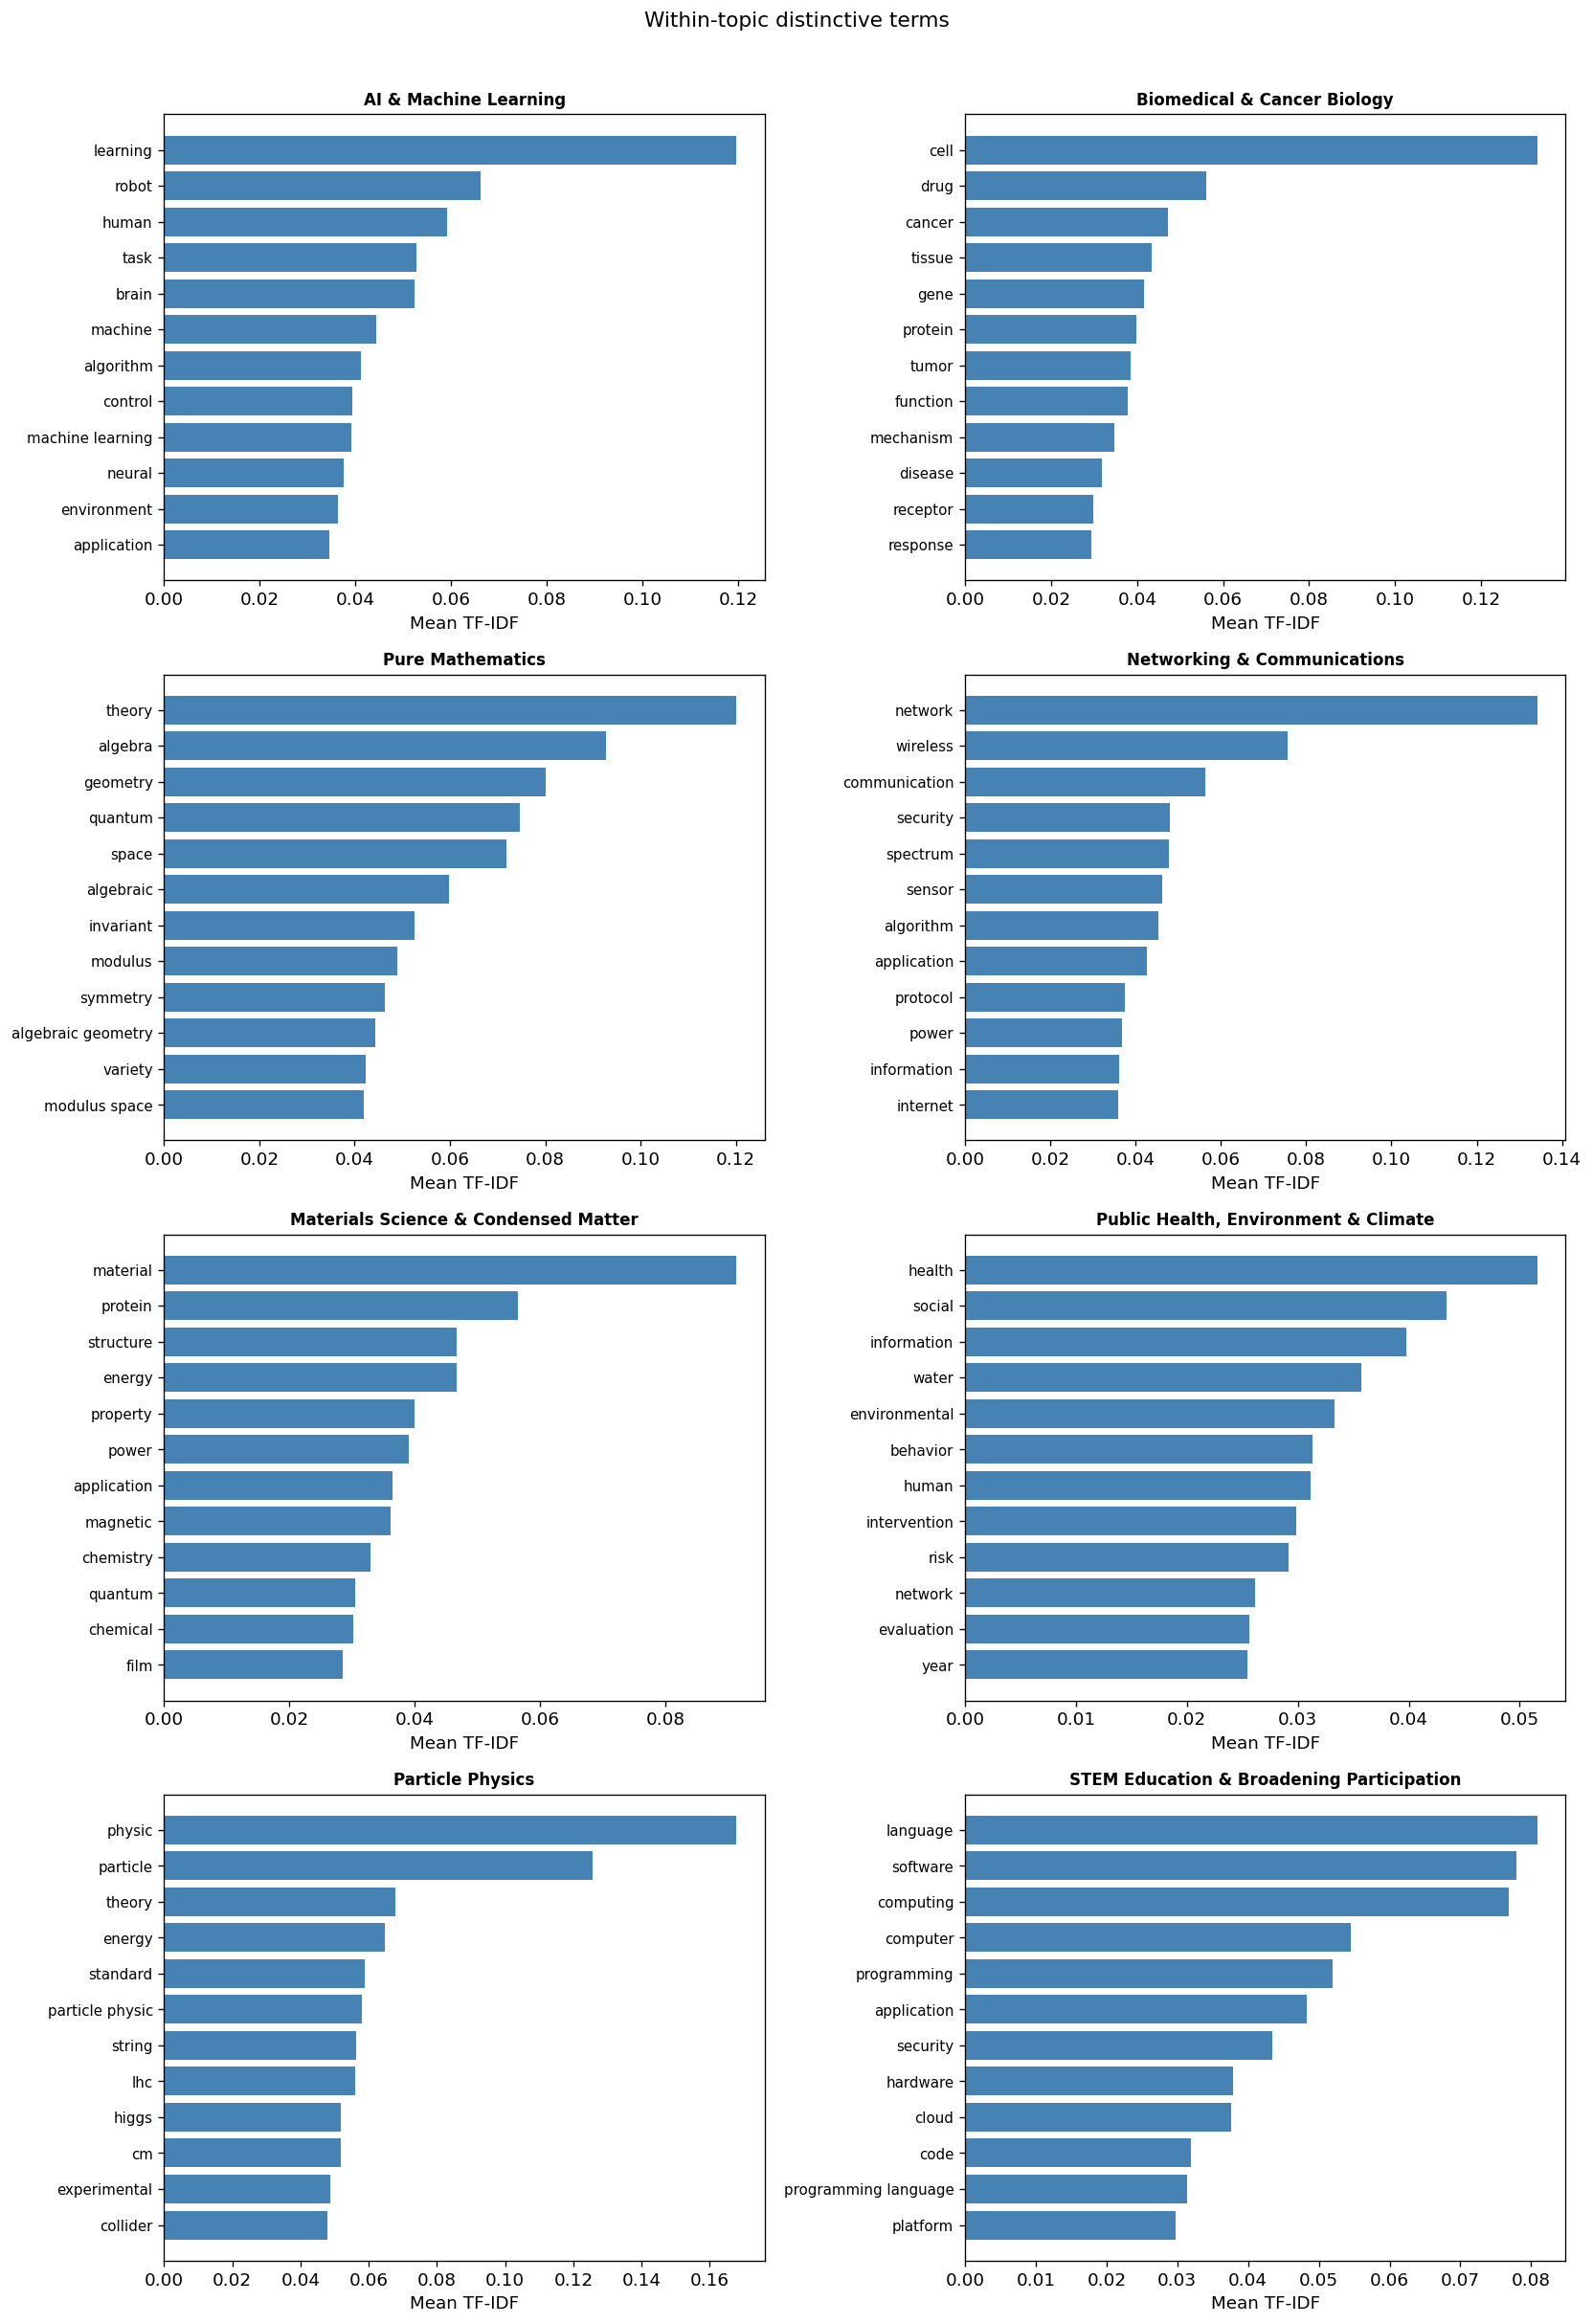

In [19]:
# visualize within-topic terms as small bar charts (one panel per topic)
fig, axes = plt.subplots(4, 2, figsize=(14, 20))
axes = axes.flatten()

for idx, (topic_id, label) in enumerate(nmf_labels.items()):
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 15:
        axes[idx].set_visible(False)
        continue
    tv = TfidfVectorizer(stop_words=all_stops, max_features=300,
                          ngram_range=(1, 2), min_df=2)
    mat = tv.fit_transform(subset)
    mean_tfidf = mat.toarray().mean(axis=0)
    top = pd.Series(mean_tfidf, index=tv.get_feature_names_out())\
            .sort_values(ascending=False).head(12).sort_values()

    axes[idx].barh(range(len(top)), top.values, color='steelblue')
    axes[idx].set_yticks(range(len(top)))
    axes[idx].set_yticklabels(top.index, fontsize=9)
    axes[idx].set_title(label, fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Mean TF-IDF')

plt.suptitle('Within-topic distinctive terms',
             y=1.01, fontsize=13)
plt.tight_layout()
plt.savefig('figures/within_topic_terms.png', dpi=150, bbox_inches='tight')
plt.show()

In [20]:
# sub-topic modeling: run NMF within each topic with n=3 sub-topics
# this reveals the internal structure of each broad area
print('SUB-TOPICS WITHIN EACH NMF TOPIC (n=3 each)')
print(' ' * 60)

for topic_id, label in nmf_labels.items():
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 30:
        print(f'\n{label}: too few grants for sub-topics ({len(subset)})')
        continue

    tv  = TfidfVectorizer(stop_words=all_stops, max_features=1000,
                           ngram_range=(1, 2), min_df=2, max_df=0.8)
    mat = tv.fit_transform(subset)
    sub_nmf  = NMF(n_components=3, random_state=42, max_iter=300)
    sub_nmf.fit(mat)
    names = tv.get_feature_names_out()

    print(f'\n{label} ({len(subset)} grants):')
    for i, comp in enumerate(sub_nmf.components_):
        words = [names[j] for j in comp.argsort()[:-8:-1]]
        print(f'  Sub-{i+1}: {" | ".join(words)}')

SUB-TOPICS WITHIN EACH NMF TOPIC (n=3 each)
                                                            

AI & Machine Learning (297 grants):
  Sub-1: learning | machine | machine learning | algorithm | brain | neural | application
  Sub-2: worker | manufacturing | skill | intelligent | ixr | job | task
  Sub-3: robot | human | human robot | object | control | task | autonomous

Biomedical & Cancer Biology (363 grants):
  Sub-1: cell | tissue | gene | mechanical | function | biology | network
  Sub-2: tumor | cancer | drug | therapy | delivery | cell | lung
  Sub-3: compound | drug | receptor | lead | ligand | agonist | protein

Pure Mathematics (139 grants):
  Sub-1: modulus | space | modulus space | sheaf | geometry | variety | curve
  Sub-2: algebra | quantum | noncommutative | cluster | auslander | invariant | symmetry
  Sub-3: postdoctoral | geometry | algebraic geometry | algebraic | mentoring | geometry theory | course

Networking & Communications (356 grants):
  Sub-1: security

In [21]:
# try different number of topics and see how change
# adding subheaders for subtopics within each main topic
print('SUB-TOPICS WITHIN EACH NMF TOPIC (n=4 each)')
print(' ' * 60)

for topic_id, label in nmf_labels.items():
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 30:
        print(f'\n{label}: too few grants for sub-topics ({len(subset)})')
        continue

    tv  = TfidfVectorizer(stop_words=all_stops, max_features=1000,
                           ngram_range=(1, 2), min_df=2, max_df=0.8)
    mat = tv.fit_transform(subset)
    sub_nmf  = NMF(n_components=4, random_state=42, max_iter=300)
    sub_nmf.fit(mat)
    names = tv.get_feature_names_out()

    print(f'\n{label} ({len(subset)} grants):')
    for i, comp in enumerate(sub_nmf.components_):
        words = [names[j] for j in comp.argsort()[:-8:-1]]
        print(f'  Sub-{i+1}: {" | ".join(words)}')

SUB-TOPICS WITHIN EACH NMF TOPIC (n=4 each)
                                                            

AI & Machine Learning (297 grants):
  Sub-1: learning | machine | machine learning | algorithm | application | deep | robustness
  Sub-2: worker | manufacturing | skill | intelligent | ixr | task | job
  Sub-3: robot | human | human robot | object | autonomous | task | control
  Sub-4: brain | neural | fear | cognitive | human | individual | neuron

Biomedical & Cancer Biology (363 grants):
  Sub-1: cell | tissue | mechanical | force | motility | neural | response
  Sub-2: tumor | cancer | drug | therapy | delivery | lung | lung cancer
  Sub-3: drug | compound | receptor | ligand | lead | agonist | inhibitor
  Sub-4: gene | network | protein | function | plant | dna | genome

Pure Mathematics (139 grants):
  Sub-1: modulus | space | modulus space | sheaf | geometry | variety | curve
  Sub-2: quantum | algebra | noncommutative | symmetry | invariant | poisson | lie
  Sub-3: postdoct

In [22]:
# try different number of topics
print('SUB-TOPICS WITHIN EACH NMF TOPIC (n=5 each)')
print(' ' * 60)

for topic_id, label in nmf_labels.items():
    subset = aa[aa['nmf_topic'] == topic_id]['full_text_lemma']
    if len(subset) < 30:
        print(f'\n{label}: too few grants for sub-topics ({len(subset)})')
        continue

    tv  = TfidfVectorizer(stop_words=all_stops, max_features=1000,
                           ngram_range=(1, 2), min_df=2, max_df=0.8)
    mat = tv.fit_transform(subset)
    sub_nmf  = NMF(n_components=5, random_state=42, max_iter=300)
    sub_nmf.fit(mat)
    names = tv.get_feature_names_out()

    print(f'\n{label} ({len(subset)} grants):')
    for i, comp in enumerate(sub_nmf.components_):
        words = [names[j] for j in comp.argsort()[:-8:-1]]
        print(f'  Sub-{i+1}: {" | ".join(words)}')

SUB-TOPICS WITHIN EACH NMF TOPIC (n=5 each)
                                                            

AI & Machine Learning (297 grants):
  Sub-1: learning | machine | machine learning | algorithm | robustness | deep | learning algorithm
  Sub-2: worker | manufacturing | skill | intelligent | ixr | task | job
  Sub-3: robot | human | human robot | object | autonomous | task | control
  Sub-4: brain | neural | fear | cognitive | human | individual | neuron
  Sub-5: learning | family | teacher | capstone | physical | game | world

Biomedical & Cancer Biology (363 grants):
  Sub-1: cell | tissue | mechanical | force | motility | response | neural
  Sub-2: tumor | cancer | drug | therapy | delivery | lung | lung cancer
  Sub-3: drug | compound | receptor | ligand | lead | agonist | inhibitor
  Sub-4: gene | protein | network | dna | function | genome | mechanism
  Sub-5: plant | alkaloid | production | defense | catharanthus | roseus | biosynthesis

Pure Mathematics (139 grants):
  Sub

In [23]:
# summary: confidence and coherence side by side
summary = pd.DataFrame({
    'topic':       [nmf_labels[i] for i in range(N_TOPICS)],
    'num_grants':  [int((aa['nmf_topic'] == i).sum()) for i in range(N_TOPICS)],
    'coherence':   [round(s, 3) for s in nmf_coherence],
    'mean_conf':   [round(aa[aa['nmf_topic']==i]['nmf_top_prob'].mean(), 3) for i in range(N_TOPICS)],
    'high_conf_pct': [round((aa[aa['nmf_topic']==i]['nmf_top_prob'] > 0.6).mean() * 100, 1)
                      for i in range(N_TOPICS)],
}).set_index('topic').sort_values('coherence', ascending=False)

print('NMF topic quality summary:')
print(summary.to_string())

NMF topic quality summary:
                                           num_grants  coherence  mean_conf  high_conf_pct
topic                                                                                     
Particle Physics                                   81      0.684      0.736           65.4
Pure Mathematics                                  139      0.457      0.790           79.9
STEM Education & Broadening Participation         251      0.341      0.628           51.8
Biomedical & Cancer Biology                       363      0.316      0.671           55.9
Networking & Communications                       356      0.301      0.627           52.0
Materials Science & Condensed Matter              474      0.242      0.626           48.7
AI & Machine Learning                             297      0.210      0.590           40.7
Public Health, Environment & Climate              912      0.122      0.644           55.2


### Connecting the topic results back to the funding and college analysis

In [24]:
# load copi and faculty files to get college information
import os
copi_raw    = pd.read_excel(BASE_PATH + 'grants-with-coPI.xlsx',
                             sheet_name='Grants with co PI indicator (1)')
faculty_raw = pd.read_excel(BASE_PATH + 'faculty-list-2025.xlsx', sheet_name='Sheet1')

# deduplicate copi to one row per grant (keep PI row)
copi_deduped = copi_raw.sort_values(['GrantId','IsCoPI']).drop_duplicates(
    subset='GrantId', keep='first').copy()

# attach college from faculty
faculty_slim = faculty_raw[['Employee ID','Superior_Academic_Unit','Academic Track Type']].rename(
    columns={'Employee ID':'ClientFacultyId'})
copi_with_college = copi_deduped.merge(faculty_slim, on='ClientFacultyId', how='left')

print(f'copi unique grants     : {len(copi_deduped):,}')
print(f'copi with college      : {copi_with_college["Superior_Academic_Unit"].notna().sum():,}')
print(f'Unique colleges        : {copi_with_college["Superior_Academic_Unit"].nunique()}')

copi unique grants     : 2,670
copi with college      : 2,530
Unique colleges        : 10


In [25]:
# join abstract file to copi via title match
# 85% of titles match exactly, best available key between the two files
# normalize titles: strip whitespace, lowercase
aa['title_key']          = aa['Title'].fillna('').str.strip().str.lower()
copi_with_college['title_key'] = copi_with_college['GrantName'].fillna('').str.strip().str.lower()

# keep only the columns we need from copi
copi_slim = copi_with_college[['title_key','Superior_Academic_Unit',
                                'Academic Track Type','AgencyName',
                                'TotalDollars','StartDateYear']].copy()

# join
aa_with_college = aa.merge(copi_slim, on='title_key', how='left')

matched   = aa_with_college['Superior_Academic_Unit'].notna().sum()
unmatched = aa_with_college['Superior_Academic_Unit'].isnull().sum()

print(f'Abstracts matched to college : {matched:,}  ({matched/len(aa)*100:.1f}%)')
print(f'Unmatched (no college info)  : {unmatched:,}')

# unmatched grants are either titles not in copi, or departed faculty
# All college-topic figures use the matched subset only

Abstracts matched to college : 2,782  (96.8%)
Unmatched (no college info)  : 502


In [26]:
# grant count per college per NMF topic
# shows which colleges dominate which research areas
college_topic_count = (
    aa_with_college
    .dropna(subset=['Superior_Academic_Unit'])
    .groupby(['Superior_Academic_Unit','nmf_label'])
    .size()
    .unstack(fill_value=0)
)
# remove placeholder college
college_topic_count= college_topic_count[~college_topic_count.index.isin(['Northeastern University'])]

# shorten college names for readability
college_topic_count.index = [
    c.replace('College of ','').replace('Khoury College of ','Khoury/')
     .replace('Bouvé College of ','Bouvé/').replace("D'Amore-McKim School of Business","D'Amore-McKim")
    for c in college_topic_count.index
]

print('Grant count per college per topic:')
print(college_topic_count.to_string())

Grant count per college per topic:
nmf_label                       AI & Machine Learning  Biomedical & Cancer Biology  Materials Science & Condensed Matter  Networking & Communications  Particle Physics  Public Health, Environment & Climate  Pure Mathematics  STEM Education & Broadening Participation
Bouvé Health Sciences                              29                           84                                     4                            1                 0                                    68                 1                                          3
Arts, Media and Design                             18                            0                                     0                            0                 0                                    28                 0                                          7
Engineering                                       125                          105                                   214                          228               

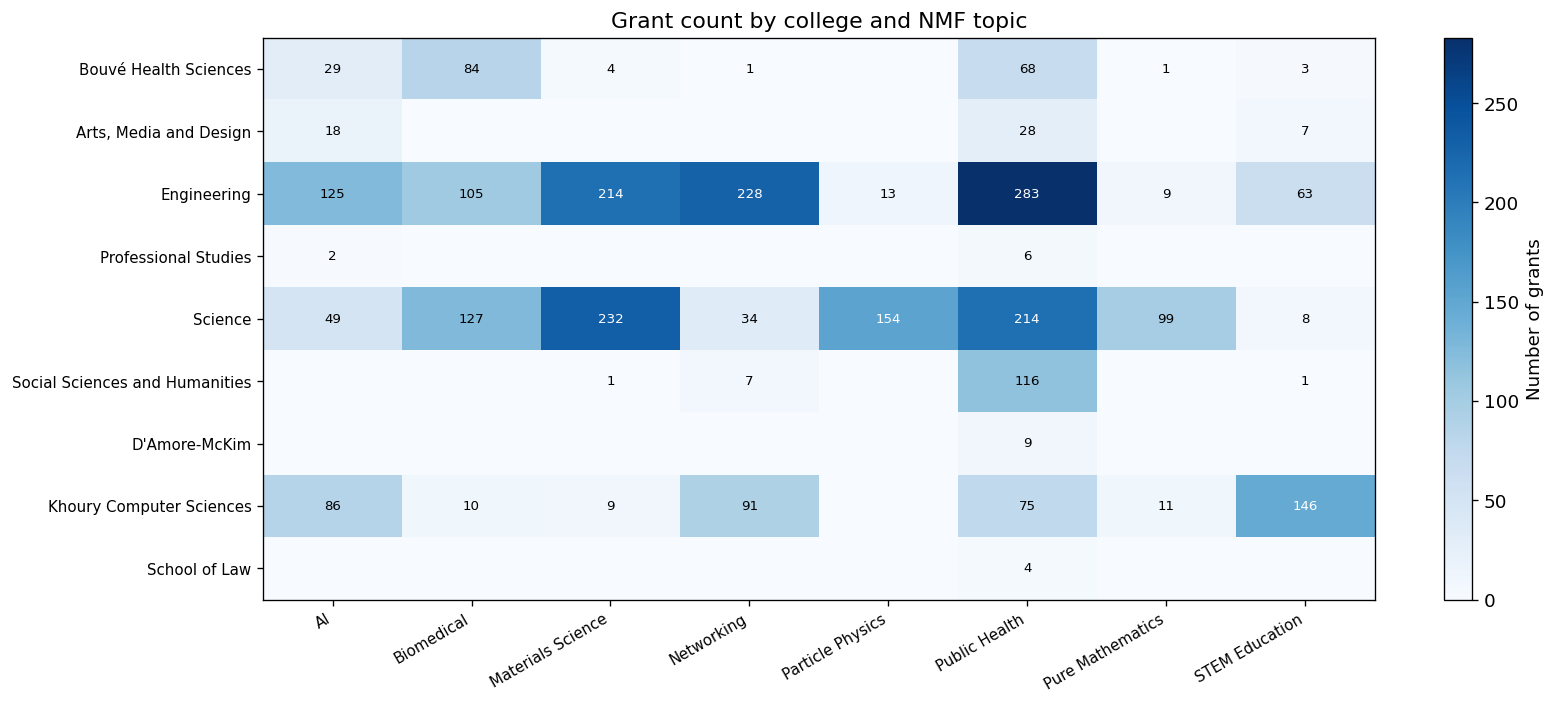

In [27]:
# heatmap: college x NMF topic, grant count

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(college_topic_count.values, cmap='Blues', aspect='auto')

ax.set_xticks(range(len(college_topic_count.columns)))
ax.set_xticklabels([c.split(' &')[0].split(',')[0]
                    for c in college_topic_count.columns],
                   rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(college_topic_count.index)))
ax.set_yticklabels(college_topic_count.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Number of grants')

for i in range(len(college_topic_count.index)):
    for j in range(len(college_topic_count.columns)):
        val = college_topic_count.values[i, j]
        if val > 0:
            ax.text(j, i, str(val), ha='center', va='center', fontsize=8,
                    color='white' if val > college_topic_count.values.max()*0.5 else 'black')

ax.set_title('Grant count by college and NMF topic')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/college_topic_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

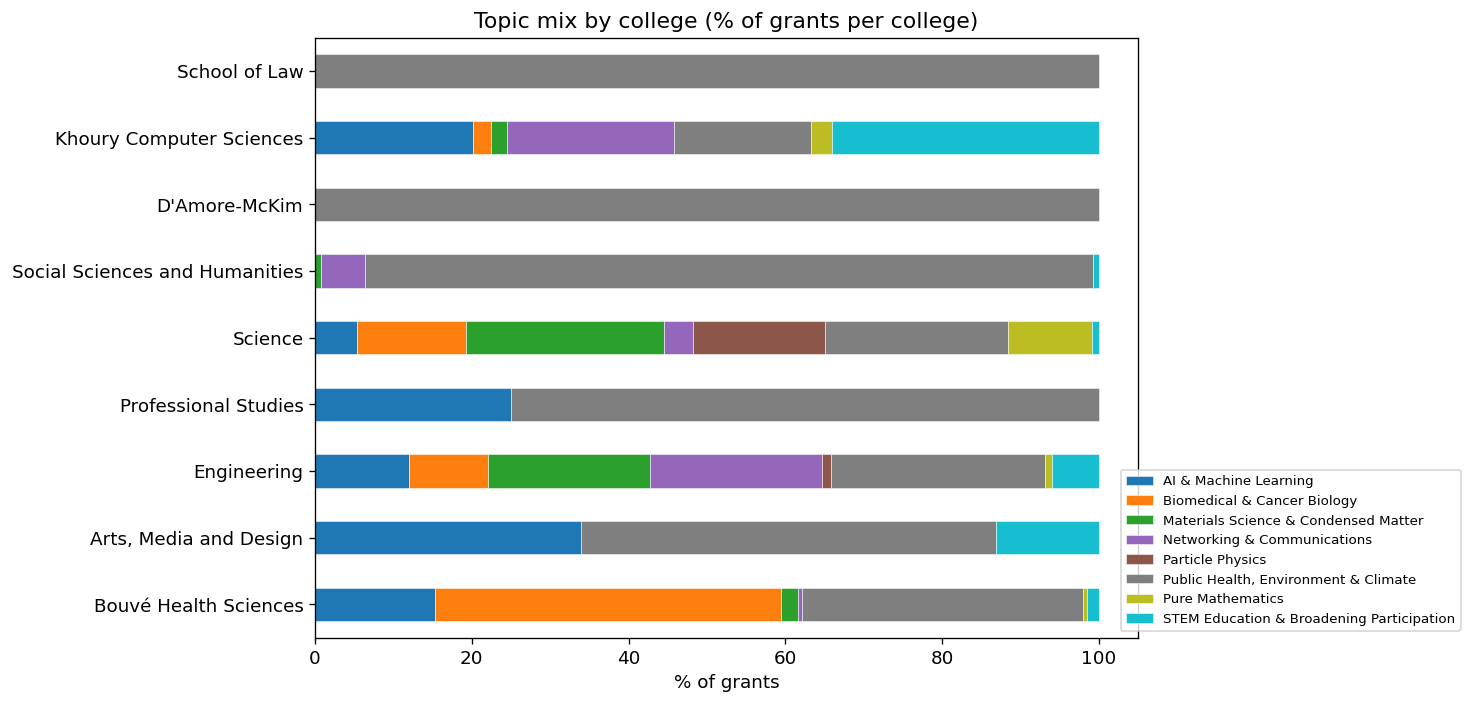

In [28]:
# normalize by total grants per college — shows topic mix, not just size
college_topic_pct = college_topic_count.div(college_topic_count.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(14, 6))
college_topic_pct.plot(kind='barh', stacked=True, ax=ax,
                        colormap='tab10', edgecolor='white', linewidth=0.3)
ax.set_xlabel('% of grants')
ax.set_title('Topic mix by college (% of grants per college)')
ax.legend(loc='lower right', fontsize=8, bbox_to_anchor=(1.40, 0))
plt.tight_layout()
plt.savefig('figures/college_topic_mix.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# which topic dominates each college? — one row per college
dominant_topic = college_topic_count.idxmax(axis=1).rename('dominant_topic')
dominant_pct   = (college_topic_count.max(axis=1) / college_topic_count.sum(axis=1) * 100).round(1).rename('pct')

college_profile = pd.concat([dominant_topic, dominant_pct, college_topic_count.sum(axis=1).rename('total_grants')], axis=1)
college_profile = college_profile.sort_values('total_grants', ascending=False)

print('Dominant topic per college:')
print(college_profile.to_string())

Dominant topic per college:
                                                           dominant_topic    pct  total_grants
Engineering                          Public Health, Environment & Climate   27.2          1040
Science                              Materials Science & Condensed Matter   25.3           917
Khoury Computer Sciences        STEM Education & Broadening Participation   34.1           428
Bouvé Health Sciences                         Biomedical & Cancer Biology   44.2           190
Social Sciences and Humanities       Public Health, Environment & Climate   92.8           125
Arts, Media and Design               Public Health, Environment & Climate   52.8            53
D'Amore-McKim                        Public Health, Environment & Climate  100.0             9
Professional Studies                 Public Health, Environment & Climate   75.0             8
School of Law                        Public Health, Environment & Climate  100.0             4


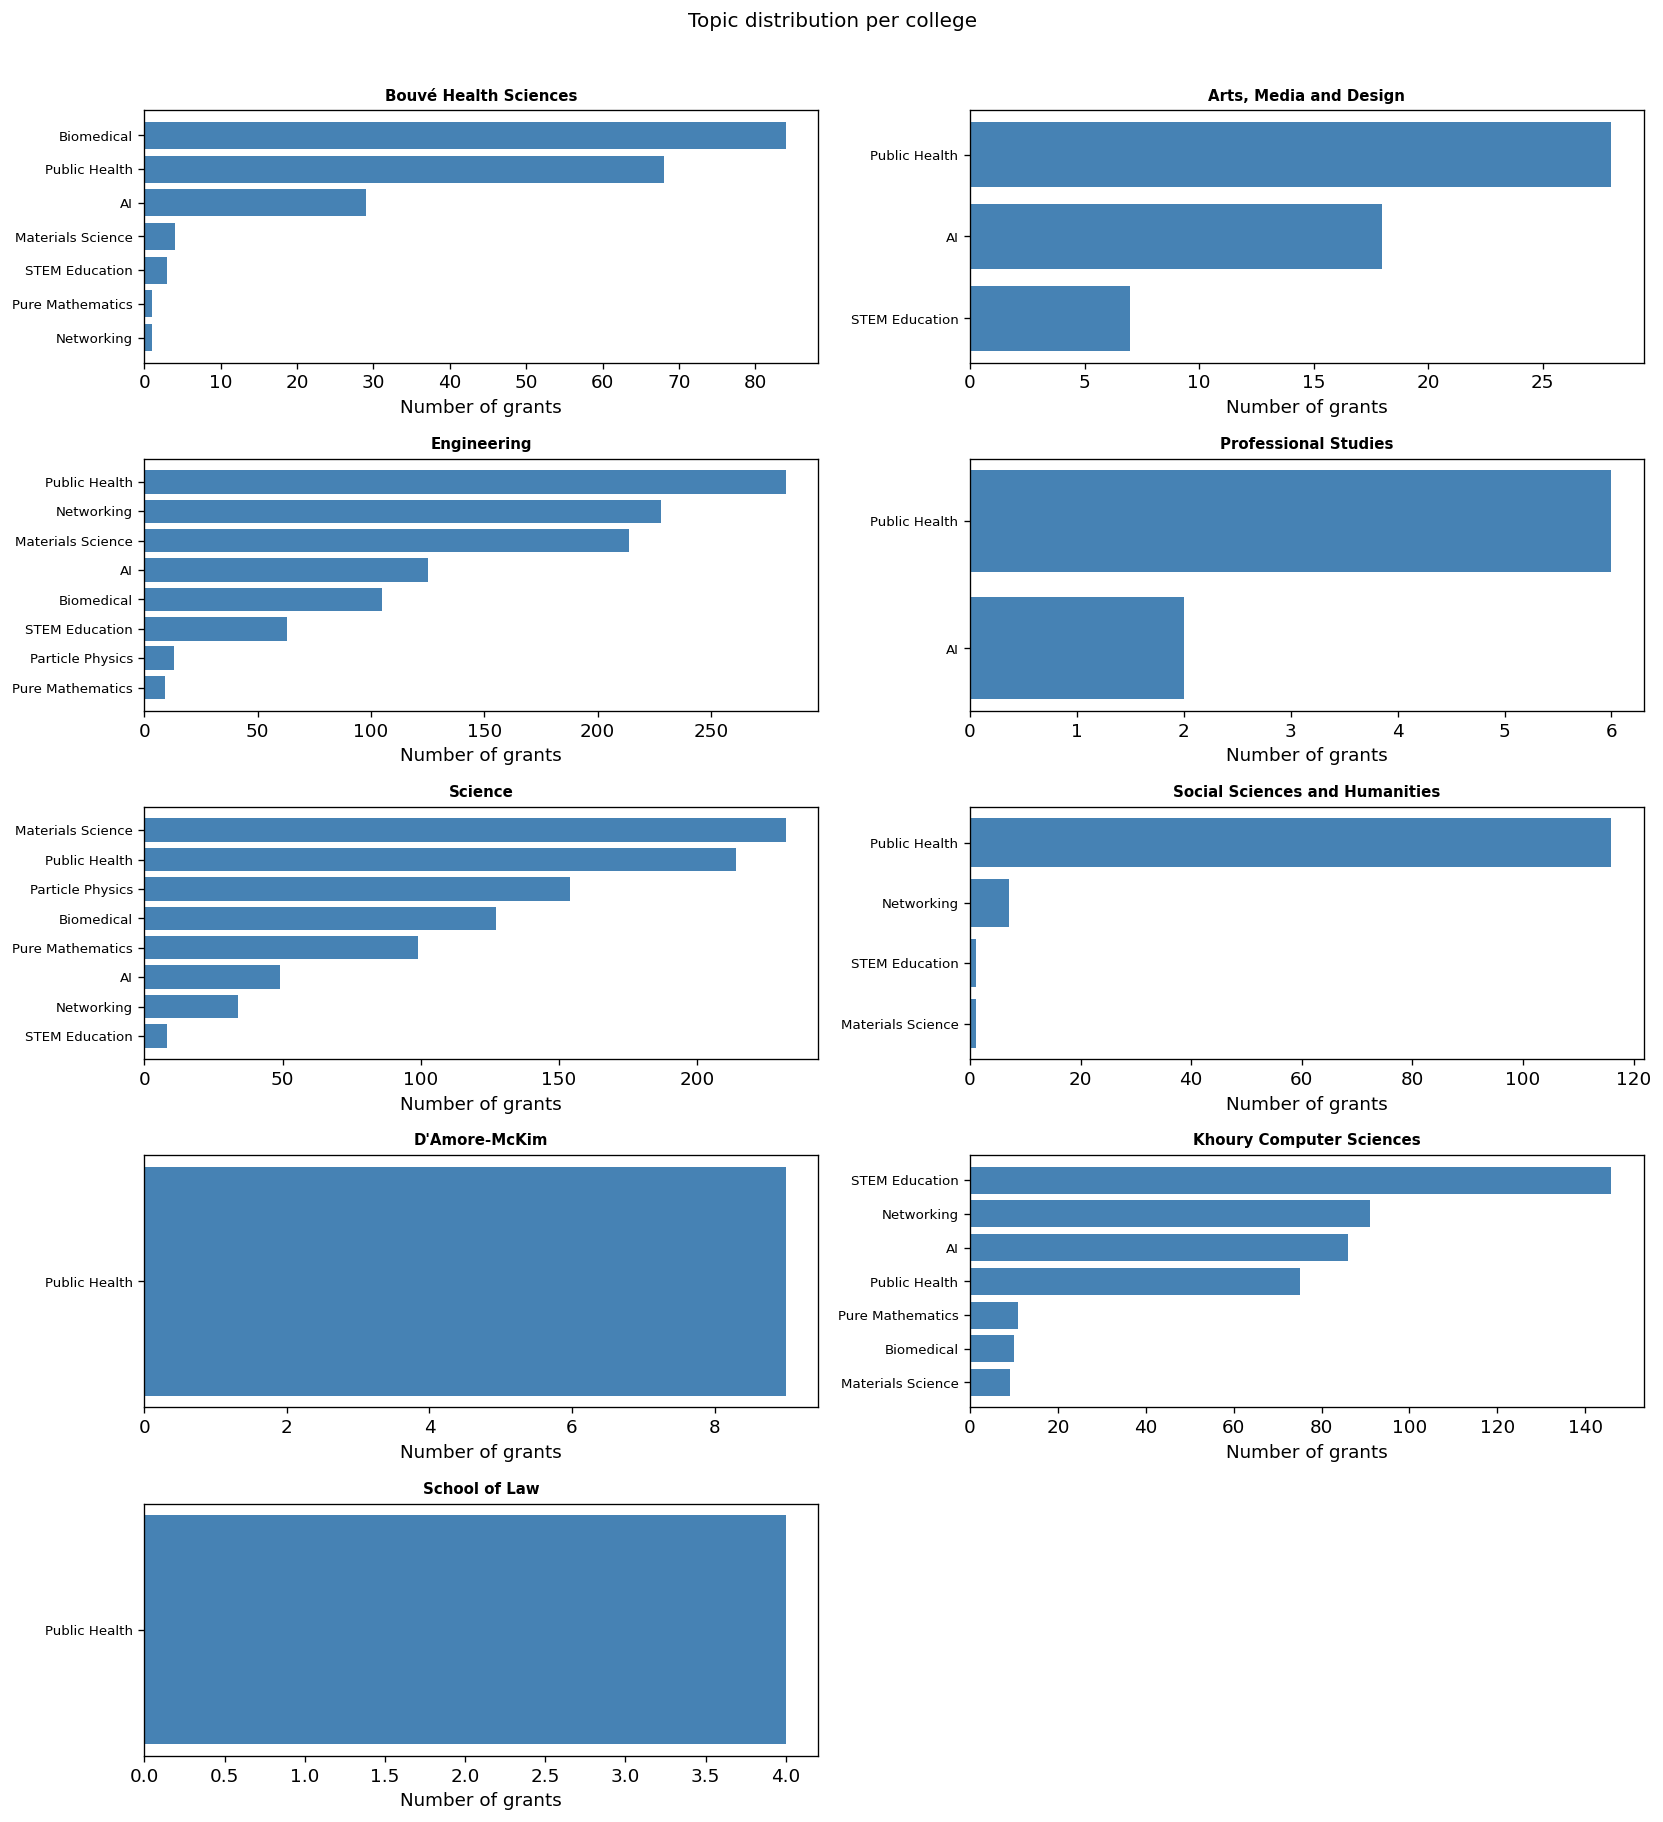

In [30]:
# topic distribution for each college individually, small multiples
colleges = college_topic_count.index.tolist()
n_cols   = 2
n_rows   = (len(colleges) + 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, n_rows * 3))
axes = axes.flatten()

for i, college in enumerate(colleges):
    row = college_topic_count.loc[college].sort_values(ascending=True)
    row = row[row > 0]
    axes[i].barh(range(len(row)), row.values, color='steelblue')
    axes[i].set_yticks(range(len(row)))
    axes[i].set_yticklabels([c.split(' &')[0].split(',')[0]
                              for c in row.index], fontsize=8)
    axes[i].set_title(college, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('Number of grants')

for j in range(len(colleges), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Topic distribution per college', y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('figures/college_topic_profiles.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# summary: top colleges per topic
print('TOP 3 COLLEGES PER NMF TOPIC')
print('' * 60)
for topic in college_topic_count.columns:
    top3 = college_topic_count[topic].sort_values(ascending=False).head(3)
    top3 = top3[top3 > 0]
    print(f'\n{topic}:')
    for college, count in top3.items():
        pct = count / college_topic_count[topic].sum() * 100
        print(f'  {college:<40} {count:>4} grants  ({pct:.1f}%)')

TOP 3 COLLEGES PER NMF TOPIC


AI & Machine Learning:
  Engineering                               125 grants  (40.5%)
  Khoury Computer Sciences                   86 grants  (27.8%)
  Science                                    49 grants  (15.9%)

Biomedical & Cancer Biology:
  Science                                   127 grants  (39.0%)
  Engineering                               105 grants  (32.2%)
  Bouvé Health Sciences                      84 grants  (25.8%)

Materials Science & Condensed Matter:
  Science                                   232 grants  (50.4%)
  Engineering                               214 grants  (46.5%)
  Khoury Computer Sciences                    9 grants  (2.0%)

Networking & Communications:
  Engineering                               228 grants  (63.2%)
  Khoury Computer Sciences                   91 grants  (25.2%)
  Science                                    34 grants  (9.4%)

Particle Physics:
  Science                                   154 grants  (92.2%